In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.calibration import CalibratedClassifierCV  # Added for calibration
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

import splitflow.TripletLoss as CCL
from splitflow.PlotUtilities import *
import splitflow.RFClassifier as RF
import figurefirst as fifi
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


import gc
gc.collect()
#with tf.device('/cpu:2'):
#    gc.collect()

Using device: cpu


20

In [2]:

plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 6
plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'

In [3]:
layout = fifi.svg_to_axes.FigureLayout('f4_template.svg',autogenlayers=True, make_mplfigures=True, hide_layers=[])

FileNotFoundError: [Errno 2] No such file or directory: 'f4_template.svg'

# Import Training Trajectories

In [91]:
middf = pd.read_hdf('../../../Data/Simulated_Trajectory_Data/training_sims_6_classes.hdf')
#print("Loading data...")

In [93]:
class_labels={
   0: 'Casting Sim', 
    1: 'Circling Sim',
    2:  'random turns',
    3: 'brownian', 
    4:'levy flight',
    5:'run and tumble'
}

In [99]:
middf.loc[middf.dataset_name=='Casting Sim','color'] = 'orangered'
middf.loc[middf.dataset_name=='Circling Sim','color'] = 'darkcyan' 
middf.loc[middf.dataset_name=='run and tumble','color'] = 'darkviolet'
middf.loc[middf.dataset_name=='levysmooth','color'] = 'yellow'
middf.loc[middf.dataset_name=='150ms_to_450ms_random_turns','color'] = 'orchid'
middf.loc[middf.dataset_name=='brownian','color'] = 'lime'



In [101]:


trajectories = np.array([
    group[['x', 'y','xvel','yvel' ]].values 
    for _, group in middf[ (middf['time stamp'].between(1100,3000))].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])
        
print(f"Result shape: {trajectories.shape}")

labels = middf.groupby('obj_id_unique').first()['dataset_numeric'].values

obj_id_values = middf.groupby('obj_id_unique').first().index

print(f"Trajectories shape: {trajectories.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Number of classes: {len(np.unique(labels))}")

Result shape: (60000, 191, 4)
Trajectories shape: (60000, 191, 4)
Labels shape: (60000,)
Number of classes: 6


In [102]:

print(f"Trajectories shape: {trajectories.shape}")  # Should be (1500, 200, 4)
print(f"Features: [x, y, xvel, yvel]")
print(f"Labels shape: {labels.shape}")
num_clusters=len(np.unique(labels))


obj_id_values =  middf.groupby('obj_id_unique').first().index#.values

color_values = middf.groupby('obj_id_unique').first()['color']


#color_values =  middf[(middf['obj_id_unique'].isin(subsample_ids ))].groupby('obj_id_unique').first()['color']#middf.groupby('obj_id_unique').first()['color']





# Split data
X_train, X_test, y_train, y_test,obj_train, obj_test, color_train,color_test = train_test_split(
    trajectories, labels, obj_id_values, color_values, test_size=0.2, random_state=42, stratify=labels
)

print(X_train.shape[0])

# Create datasets and dataloaders
train_dataset = CCL.TrajectoryDataset(X_train, y_train, obj_train, normalization_type='zero_mean')
test_dataset = CCL.TrajectoryDataset(X_test, y_test, obj_test, normalization_type='zero_mean')

train_loader = CCL.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = CCL.DataLoader(test_dataset, batch_size=64, shuffle=False)
# Initialize and train Clustering VAE
print("Training Clustering VAE with cluster-center loss...")



input_dim = X_train.shape[1] * X_train.shape[2]  # 191 * 4 = 764

num_clusters = len(np.unique(labels))


print(f"Input dimension: {input_dim}")
print(f"Number of clusters: {num_clusters}")

Trajectories shape: (60000, 191, 4)
Features: [x, y, xvel, yvel]
Labels shape: (60000,)
48000
Training Clustering VAE with cluster-center loss...
Input dimension: 764
Number of clusters: 6


# Load in model

In [104]:
triplet_model = CCL.TripletLossVAE(input_dim=input_dim, hidden_dim=540, latent_dim=70, margin=1.5)
triplet_model.load_state_dict(torch.load("triplet_vae_6_classes_70_feats.pth"))

<All keys matched successfully>

# Load in the various fly datasets

### all c1xwt split flow data

In [26]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')
bottom_on_df['dataset_numeric'] = 100
bottom_on_df['ground speed']= np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)
#bottom_on_df = bottom_on_df#.groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))
#bottom_on_df= bottom_on_df[bottom_on_df['time stamp'].between(1100,3000)]

df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))

df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))



flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)





In [40]:


top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/all_nights_new_processing_protocol_top_laminar_09082024.hdf')
top_on_df['ground speed']= np.sqrt(top_on_df.xvel**2 + top_on_df.yvel**2)
#top_on_df = bottom_on_df#.groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))
#bottom_on_df= bottom_on_df[bottom_on_df['time stamp'].between(1100,3000)]
top_on_df['dataset_numeric'] = 100

df_flash_top_on = top_on_df[top_on_df.duration>0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15) & (d['time stamp'].max()>=3000))

df_sham_top_on =top_on_df[top_on_df.duration==0].groupby("obj_id_unique").filter(lambda d:(d['ground speed'].mean()>.15) &  (d['time stamp'].max()>=3000))



flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)



In [44]:
cmap_real = plt.get_cmap('RdBu', 16) 

flash_low_bottom_on['color'] = 'darkorange'
flash_up_bottom_on['color'] = [cmap_real(11)] * len(flash_up_bottom_on)
flash_low_top_on['color'] = [cmap_real(13)] * len(flash_low_top_on)
flash_up_top_on['color'] = [cmap_real(3)] * len(flash_up_top_on)



flash_low_bottom_on['dataset_name'] = 'Steady, z<.25'
flash_up_bottom_on['dataset_name'] = 'Unsteady, z>.25'
flash_low_top_on['dataset_name'] = 'Unsteady, z<.25'
flash_up_top_on['dataset_name'] = 'Steady, z>.25'



In [46]:
cmap_real = plt.get_cmap('RdBu', 16) 

sham_low_bottom_on['color'] = 'darkorange'
sham_up_bottom_on['color'] = [cmap_real(11)] * len(sham_up_bottom_on)
sham_low_top_on['color'] = [cmap_real(13)] * len(sham_low_top_on)
sham_up_top_on['color'] = [cmap_real(3)] * len(sham_up_top_on)



sham_low_bottom_on['dataset_name'] = 'Sham Steady, z<.25'
sham_up_bottom_on['dataset_name'] = 'Sham Unsteady, z>.25'
sham_low_top_on['dataset_name'] = 'Sham Unsteady, z<.25'
sham_up_top_on['dataset_name'] = 'Sham Steady, z>.25'



In [48]:
c1xwt_flash = pd.concat([flash_low_bottom_on,flash_up_bottom_on,flash_low_top_on,flash_up_top_on])
c1xwt_sham = pd.concat([sham_low_bottom_on,sham_up_bottom_on,sham_low_top_on,sham_up_top_on])

In [50]:
c1xwt_flash['dataset_numeric'] = pd.factorize(c1xwt_flash['dataset_name'])[0]

### Split Flow -- Flash

In [52]:
c1xwt_flash =pd.concat([flash_low_top_on,flash_up_bottom_on ])

### transform the array & labels correctly

unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unsteady_array.shape}")

# get labels
unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric']#.values

unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index#.values

print(f"Updated labels shape: {unsteady_labels.shape}")



unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_unsteady, X_test_unsteady, y_train_unsteady, y_test_unsteady, y_train_unsteady_color, y_test_unsteady_color,y_train_unsteady_obj, y_test_unsteady_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    unsteady_array, 
    unsteady_labels, 
    unsteady_color,
    unsteady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=42, 
    stratify=unsteady_labels
)

# Create datasets and dataloaders
train_dataset_unsteady = CCL.TrajectoryDataset(X_train_unsteady, y_train_unsteady,y_train_unsteady_obj,  normalization_type='zero_mean')
test_dataset_unsteady = CCL.TrajectoryDataset(X_test_unsteady, y_test_unsteady,y_test_unsteady_obj,  normalization_type='zero_mean')

train_loader_unsteady = CCL.DataLoader(train_dataset_unsteady, batch_size=32, shuffle=True)
test_loader_unsteady = CCL.DataLoader(test_dataset_unsteady, batch_size=32, shuffle=False)

Result shape: (154, 191, 4)
Updated labels shape: (154,)


In [54]:
c1xwt_flash = flash_low_bottom_on#pd.concat([flash_low_bottom_on,flash_up_top_on ])

### transform the array & labels correctly

steady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {steady_array.shape}")

# get labels
steady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric']#.values

steady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index#.values

print(f"Updated labels shape: {steady_labels.shape}")



steady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_steady, X_test_steady, y_train_steady, y_test_steady, y_train_steady_color, y_test_steady_color,y_train_steady_obj, y_test_steady_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    steady_array, 
    steady_labels, 
    steady_color,
    steady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=42, 
    stratify=steady_labels
)

# Create datasets and dataloaders
train_dataset_steady = CCL.TrajectoryDataset(X_train_steady, y_train_steady,obj_ids=y_train_steady_obj,  normalization_type='zero_mean')
test_dataset_steady = CCL.TrajectoryDataset(X_test_steady, y_test_steady,obj_ids=y_test_steady_obj,  normalization_type='zero_mean')

train_loader_steady = CCL.DataLoader(train_dataset_steady, batch_size=32, shuffle=True)
test_loader_steady = CCL.DataLoader(test_dataset_steady, batch_size=32, shuffle=False)

Result shape: (173, 191, 4)
Updated labels shape: (173,)


### Split flow -- shams

In [56]:
c1xwt_flash =pd.concat([sham_low_top_on,sham_up_bottom_on ])

### transform the array & labels correctly

sham_unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {sham_unsteady_array.shape}")

# get labels
sham_unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric']#.values

sham_unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index#.values

print(f"Updated labels shape: {sham_unsteady_labels.shape}")



sham_unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_unsteady_sham, X_test_unsteady_sham, y_train_unsteady_sham, y_test_unsteady_sham, y_train_unsteady_sham_color, y_test_unsteady_sham_color,y_train_unsteady_sham_obj, y_test_unsteady_sham_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    sham_unsteady_array, 
    sham_unsteady_labels, 
    sham_unsteady_color,
    sham_unsteady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=42, 
    stratify=sham_unsteady_labels
)

# Create datasets and dataloaders
train_dataset_unsteady_sham = CCL.TrajectoryDataset(X_train_unsteady_sham, y_train_unsteady_sham,y_train_unsteady_sham_obj,  normalization_type='zero_mean')
test_dataset_unsteady_sham = CCL.TrajectoryDataset(X_test_unsteady_sham, y_test_unsteady_sham,y_test_unsteady_sham_obj,  normalization_type='zero_mean')

train_loader_unsteady_sham = CCL.DataLoader(train_dataset_unsteady_sham, batch_size=32, shuffle=True)
test_loader_unsteady_sham = CCL.DataLoader(test_dataset_unsteady_sham, batch_size=32, shuffle=False)

Result shape: (1814, 191, 4)
Updated labels shape: (1814,)


In [58]:
c1xwt_flash =pd.concat([sham_low_bottom_on,sham_up_top_on ])

### transform the array & labels correctly

sham_steady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {sham_steady_array.shape}")

# get labels
sham_steady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric']#.values

sham_steady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index#.values

print(f"Updated labels shape: {sham_steady_labels.shape}")



sham_steady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_steady_sham, X_test_steady_sham, y_train_steady_sham, y_test_steady_sham, y_train_steady_sham_color, y_test_steady_sham_color,y_train_steady_sham_obj, y_test_steady_sham_obj   = train_test_split(
#X_train_split_flash_bottom_on, X_test_split_flash_bottom_on, y_train_split_flash_bottom_on, y_test_split_flash_bottom_on,  = train_test_split(

    sham_steady_array, 
    sham_steady_labels, 
    sham_steady_color,
    sham_steady_objids, # Include color variable in split
    test_size=0.01, 
    random_state=42, 
    stratify=sham_steady_labels
)

# Create datasets and dataloaders
train_dataset_steady_sham = CCL.TrajectoryDataset(X_train_steady_sham, y_train_steady_sham,y_train_steady_sham_obj,  normalization_type='zero_mean')
test_dataset_steady_sham = CCL.TrajectoryDataset(X_test_steady_sham, y_test_steady_sham,y_test_steady_sham_obj,  normalization_type='zero_mean')

train_loader_steady_sham = CCL.DataLoader(train_dataset_steady_sham, batch_size=32, shuffle=True)
test_loader_steady_sham = CCL.DataLoader(test_dataset_steady_sham, batch_size=32, shuffle=False)

Result shape: (1001, 191, 4)
Updated labels shape: (1001,)


# Supplement: Plot latent space + color by altitude

In [1]:
def plot_latent_space_with_labels(model, test_loader, labels=None, reduce='PCA', KDE=True, KDE_test=True,
                                 n_feats=100, path='output.svg', plotting_labels=None,
                                 train_colors=None, real_data_loaders=None, 
                                 real_data_labels_list=None, real_colors_list=None, cmap='coolwarm',
                                 ax=None, markers=None, alpha_list=None, sizes_list=None,
                                 legend_loc='best'):
    """
    Plot latent space visualization with customizable training data colors and 
    support for multiple real data loaders.
    """
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    model.eval()
    
    # Extract latent vectors for training data
    train_latent_vectors = []
    train_true_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            if len(batch) == 3:
                data, label, _ = batch
            elif len(batch) == 2:
                data, label = batch
            else:
                raise ValueError(f"Unexpected batch format")
            
            mu, logvar = model.encode(data)
            train_latent_vectors.append(mu.cpu().numpy())
            train_true_labels.extend(label.cpu().numpy())
    
    if len(train_latent_vectors) > 0:
        train_latent_vectors = np.vstack(train_latent_vectors)
        train_true_labels = np.array(train_true_labels)
    
    # Apply dimensionality reduction to training data
    if reduce == 'PCA':
        from sklearn.decomposition import PCA
        reducer = PCA(n_components=2)
        train_latent_reduced = reducer.fit_transform(train_latent_vectors[:, :n_feats])
        print(f'Using PCA, explained variance: {reducer.explained_variance_ratio_}')
    elif reduce == 'UMAP':
        import umap
        reducer = umap.UMAP(n_components=2, random_state=42)
        train_latent_reduced = reducer.fit_transform(train_latent_vectors)
    elif reduce == 't-SNE':
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
        train_latent_reduced = reducer.fit_transform(train_latent_vectors)
    
    # Plot training data
    unique_train_labels = np.unique(train_true_labels)
    
    if train_colors is not None:
        # Plot training data with custom colors
        label_to_color = {}
        for i, label in enumerate(unique_train_labels):
            if i < len(train_colors):
                label_to_color[label] = train_colors[i]
            else:
                cmap = plt.cm.tab20
                label_to_color[label] = cmap(i % 20)
        
        if KDE:
            for label in unique_train_labels:
                mask = train_true_labels == label
                if np.sum(mask) > 0:
                    color = label_to_color[label]
                    class_name = f'Class {label}'
                    if plotting_labels is not None and label < len(plotting_labels):
                        class_name = plotting_labels[label]
                    
                    sns.kdeplot(
                        x=train_latent_reduced[mask, 0],
                        y=train_latent_reduced[mask, 1],
                        levels=5, thresh=0.05, fill=True, alpha=0.2,
                        color=color,
                        label=class_name,
                        legend=False, ax=ax
                    )
        else:
            train_point_colors = [label_to_color[label] for label in train_true_labels]
            ax.scatter(
                train_latent_reduced[:, 0], train_latent_reduced[:, 1],
                c=train_point_colors, alpha=0.7, s=20,
                edgecolors='k', linewidth=0.5
            )
    else:
        # Default plotting
        if KDE:
            sns.kdeplot(
                x=train_latent_reduced[:, 0],
                y=train_latent_reduced[:, 1],
                hue=train_true_labels,
                levels=5, thresh=0.05, fill=True, alpha=0.2,
                palette='viridis',
                legend=False, ax=ax
            )
        else:
            ax.scatter(
                train_latent_reduced[:, 0], train_latent_reduced[:, 1],
                c=train_true_labels, cmap='viridis', alpha=0.7, s=20,
                edgecolors='k', linewidth=0.5
            )
    
    # Plot multiple real datasets
    if real_data_loaders is not None:
        if not isinstance(real_data_loaders, list):
            real_data_loaders = [real_data_loaders]
        
        # Handle defaults
        if real_colors_list is None:
            real_colors_list = [None] * len(real_data_loaders)
        elif not isinstance(real_colors_list, list):
            real_colors_list = [real_colors_list]
        
        if real_data_labels_list is None:
            real_data_labels_list = [None] * len(real_data_loaders)
        
        # Process each real dataset
        for i, (real_loader, colors) in enumerate(zip(real_data_loaders, real_colors_list)):
            
            # Extract latent vectors
            real_latent_vectors = []
            
            with torch.no_grad():
                for batch in real_loader:
                    if len(batch) >= 2:
                        data = batch[0]
                    else:
                        raise ValueError(f"Unexpected batch format")
                    
                    mu, logvar = model.encode(data)
                    real_latent_vectors.append(mu.cpu().numpy())
            
            if len(real_latent_vectors) > 0:
                real_latent_vectors = np.vstack(real_latent_vectors)
                real_latent_reduced = reducer.transform(real_latent_vectors[:, :n_feats])
                
                # FIX: Properly handle the colors array
                if colors is not None:
                    # Ensure colors is a numpy array
                    if hasattr(colors, 'values'):
                        colors = colors.values
                    elif hasattr(colors, 'to_numpy'):
                        colors = colors.to_numpy()
                    
                    colors = np.asarray(colors)
                    
                    # Check if colors is scalar or array
                    if colors.ndim == 0 or (colors.ndim == 1 and colors.shape[0] == 1):
                        # Single color
                        ax.scatter(
                            real_latent_reduced[:, 0], real_latent_reduced[:, 1],
                            c=colors, alpha=0.7, s=1,
                            edgecolors=None, linewidth=0,
                        )
                    elif colors.shape[0] == real_latent_reduced.shape[0]:
                        # Array of colors with correct length
                        if KDE_test:
                            sns.kdeplot(
                                x=real_latent_reduced[:, 0], 
                                y=real_latent_reduced[:, 1],
                                levels=5, thresh=0.05, fill=True, alpha=0.2,
                                color='k',
                                legend=False, ax=ax
                            )
                        else:
                            # Check if colors are numeric (for colormap)
                            try:
                                # Try to use as numeric values for colormap
                                from matplotlib import colors as mcolors
                                vmin, vmax = 0,0.5 #np.min(colors), np.max(colors)
                                vcenter = (vmin + vmax) / 2
                                divnorm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
                                
                                scatter = ax.scatter(
                                    real_latent_reduced[:, 0], real_latent_reduced[:, 1],
                                    c=colors, cmap=cmap, norm=divnorm,
                                    alpha=0.7, s=1,
                                    edgecolors=None, linewidth=0,
                                )
                            except:
                                # Fall back to treating as color strings
                                ax.scatter(
                                    real_latent_reduced[:, 0], real_latent_reduced[:, 1],
                                    c=colors, alpha=0.7, s=1,
                                    edgecolors=None, linewidth=0,
                                )
                    else:
                        # Colors array length doesn't match
                        print(f"Warning: colors array length {colors.shape[0]} doesn't match data length {real_latent_reduced.shape[0]}")
                        print(f"Using default color instead")
                        ax.scatter(
                            real_latent_reduced[:, 0], real_latent_reduced[:, 1],
                            c='gray', alpha=0.7, s=1,
                            edgecolors=None, linewidth=0,
                        )
                else:
                    # No colors provided
                    if KDE_test:
                        sns.kdeplot(
                            x=real_latent_reduced[:, 0], 
                            y=real_latent_reduced[:, 1],
                            levels=5, thresh=0.05, fill=True, alpha=0.2,
                            color='k',
                            legend=False, ax=ax
                        )
                    else:
                        ax.scatter(
                            real_latent_reduced[:, 0], real_latent_reduced[:, 1],
                            c='gray', alpha=0.7, s=1,
                            edgecolors=None, linewidth=0,
                        )

    ax.set_aspect('equal')
    ax.axis('off')
    
    # Add legend
    handles, labels_legend = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles=handles, loc=legend_loc, framealpha=0.7)
    
    plt.tight_layout()
    return ax

In [2516]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    '''
    https://stackoverflow.com/a/18926541
    '''
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap



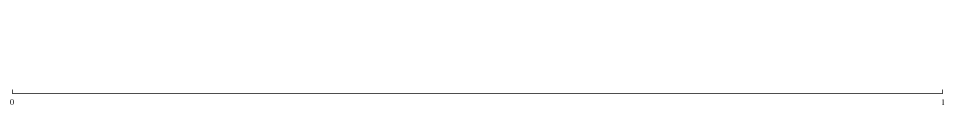

In [2573]:

fig, ax = plt.subplots(figsize=(12,1))
ax = layout.axes[('RF1', 'rf1')] 

sm = mpl.cm.ScalarMappable(cmap="vanimo", norm=mpl.colors.Normalize(vmin=0, vmax=0.5))
fig.colorbar(sm, cax=ax,  orientation='vertical')
for ax in fig.get_axes():    # <--- New line
    ax.set_rasterized(True)
fifi.mpl_functions.adjust_spines(ax, ['bottom'], xticks=[0,1], spine_locations={'bottom':5}, tick_length=3, linewidth=.5)
fifi.mpl_functions.set_fontsize(ax, 6)


layout.append_figure_to_layer(layout.figures['RF1'], 'RF1', cleartarget=True)


#ax[0].set_aspect(.1)
#ax[1].set_aspect(2)
#ax[2].set_aspect(2)


In [ ]:
bottom_on_df = pd.read_hdf('all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')
bottom_on_df['dataset_numeric'] = 100
bottom_on_df['ground speed']= np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)
#bottom_on_df = bottom_on_df#.groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))
#bottom_on_df= bottom_on_df[bottom_on_df['time stamp'].between(1100,3000)]

df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))

df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))



flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)




top_on_df = pd.read_hdf('all_nights_new_processing_protocol_top_laminar_09082024.hdf')
top_on_df['ground speed']= np.sqrt(top_on_df.xvel**2 + top_on_df.yvel**2)
#top_on_df = bottom_on_df#.groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15)& (d['time stamp'].max()>=3000))
#bottom_on_df= bottom_on_df[bottom_on_df['time stamp'].between(1100,3000)]
top_on_df['dataset_numeric'] = 100
df_flash_top_on = top_on_df[top_on_df.duration>0].groupby("obj_id_unique").filter(lambda d: (d['ground speed'].mean()>.15) & (d['time stamp'].max()>=3000))

df_sham_top_on =top_on_df[top_on_df.duration==0].groupby("obj_id_unique").filter(lambda d:(d['ground speed'].mean()>.15) &  (d['time stamp'].max()>=3000))



flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)


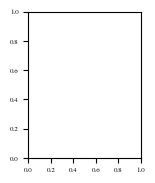

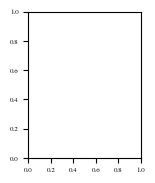

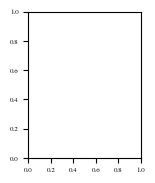

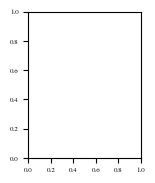

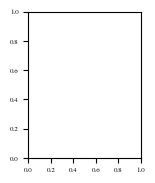

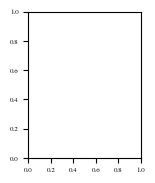

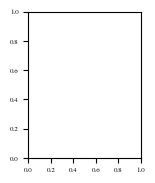

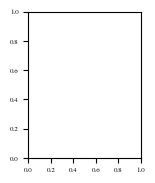

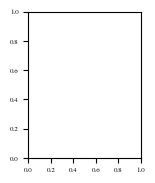

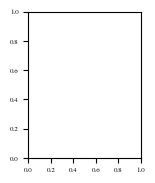

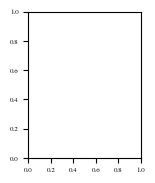

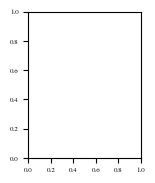

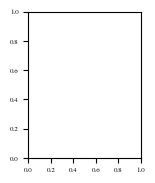

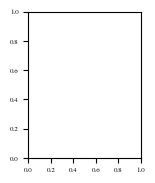

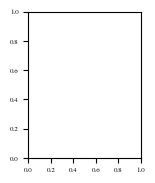

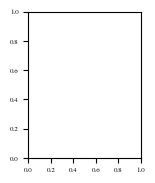

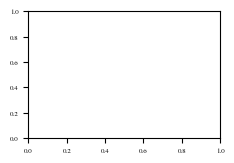

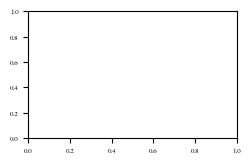

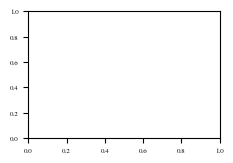

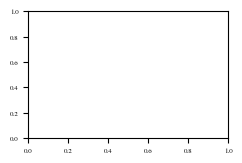

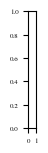

In [ ]:
layout = fifi.svg_to_axes.FigureLayout('r2_supp_all_trajectories_altitude_sorted_template.svg',autogenlayers=True, make_mplfigures=True, hide_layers=[])

In [ ]:
c1xwt_flash = df_flash_bottom_on #pd.concat([sham_low_top_on,sham_up_top_on ])
c1xwt_flash =  c1xwt_flash.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
                                                        
### transform the array & labels correctly

sham_unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {sham_unsteady_array.shape}")

# get labels
sham_unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric']#.values

sham_unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index#.values

print(f"Updated labels shape: {sham_unsteady_labels.shape}")


sham_unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].mean().rename('Mean_z_after_odor').values


# Now split while maintaining correspondence
X_train_unsteady_sham =  sham_unsteady_array
y_train_unsteady_sham = sham_unsteady_labels
y_train_unsteady_sham_color= sham_unsteady_color
y_train_unsteady_sham_obj = sham_unsteady_objids  



# Create datasets and dataloaders
train_dataset_unsteady_sham = CCL.TrajectoryDataset(X_train_unsteady_sham, y_train_unsteady_sham,y_train_unsteady_sham_obj,  normalization_type='zero_mean')
train_loader_unsteady_sham = CCL.DataLoader(train_dataset_unsteady_sham, batch_size=32, shuffle=False)


In [ ]:

latent_vectors, true_labels, latent_tsne, train_objs, real_latent_vectors, real_true_labels, real_latent_tsne, real_obj_ids = CCL.plot_latent_space_with_labels(triplet_model, 
                                                                          test_loader = train_loader, 
                                                                          labels=y_train,
                                                                          real_data_loader=train_loader_unsteady_sham, 
                                                                          real_data_labels=y_train_unsteady_sham,
                                                                          # path='latent_imgs/train_dataset_split_sham_unsteady.svg',                                                          
                                                                          reduce='PCA', 
                                                                          n_feats=70, 
                                                                         KDE=True,
                                                                          real_colors= y_train_unsteady_sham_color,
                                                                          plotting_labels=class_labels,)
                                                                          #real_colors = color_train)

In [ ]:
fig, ax = plt.subplots()

ax = layout.axes[('PCA1', 'pca1')]


ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',
    KDE=True, KDE_test=False,
    real_data_loaders=train_loader_unsteady_sham, cmap = "vanimo",
    real_colors_list=y_train_unsteady_sham_color,  # Use converted array
    ax=ax
)


layout.append_figure_to_layer(layout.figures['PCA1'], 'PCA1', cleartarget=True)#

In [2569]:
c1xwt_flash = df_flash_top_on #pd.concat([sham_low_top_on,sham_up_top_on ])
c1xwt_flash =  c1xwt_flash.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
                                                        
### transform the array & labels correctly

sham_unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {sham_unsteady_array.shape}")

# get labels
sham_unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric']#.values

sham_unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index#.values

print(f"Updated labels shape: {sham_unsteady_labels.shape}")


sham_unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].mean().rename('Mean_z_after_odor').values


# Now split while maintaining correspondence
X_train_unsteady_sham =  sham_unsteady_array
y_train_unsteady_sham = sham_unsteady_labels
y_train_unsteady_sham_color= sham_unsteady_color
y_train_unsteady_sham_obj = sham_unsteady_objids  



# Create datasets and dataloaders
train_dataset_unsteady_sham = CCL.TrajectoryDataset(X_train_unsteady_sham, y_train_unsteady_sham,y_train_unsteady_sham_obj,  normalization_type='zero_mean')
train_loader_unsteady_sham = CCL.DataLoader(train_dataset_unsteady_sham, batch_size=32, shuffle=False)


Result shape: (910, 191, 4)
Updated labels shape: (910,)


Using PCA, explained variance: [0.2597884  0.23014233]


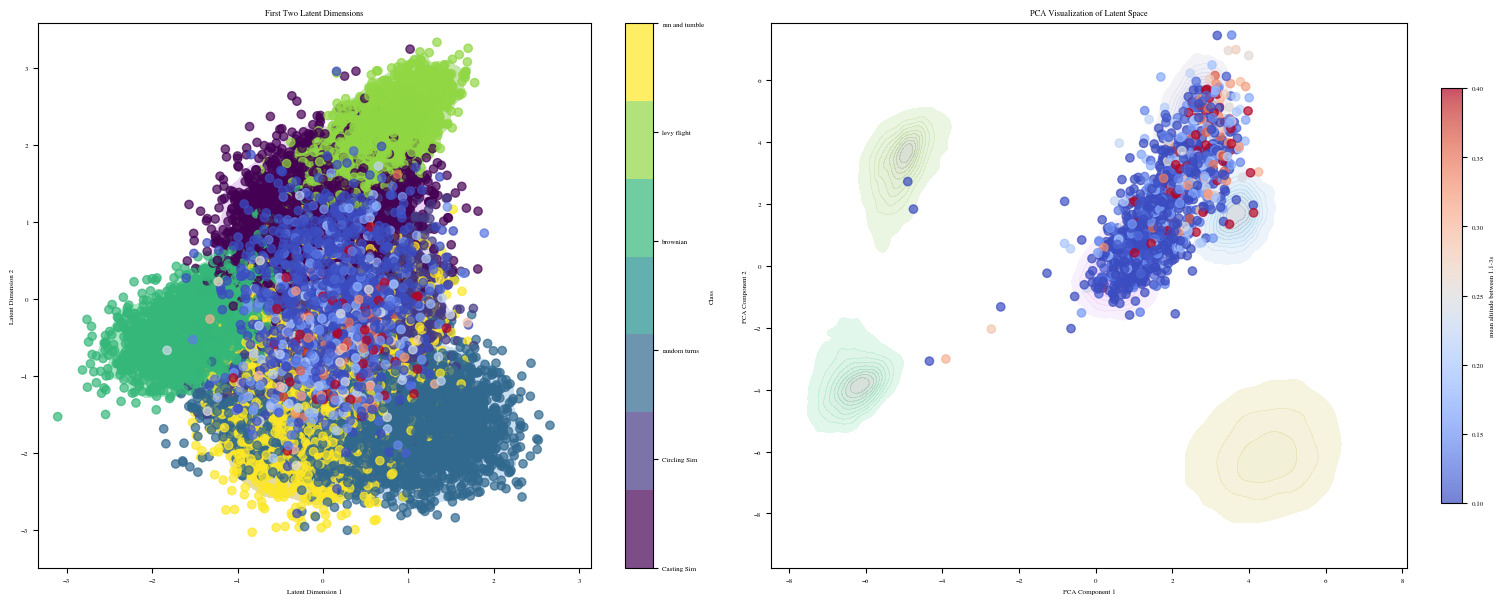

In [2527]:

latent_vectors, true_labels, latent_tsne, train_objs, real_latent_vectors, real_true_labels, real_latent_tsne, real_obj_ids = CCL.plot_latent_space_with_labels(triplet_model, 
                                                                          test_loader = train_loader, 
                                                                          labels=y_train,
                                                                          real_data_loader=train_loader_unsteady_sham, 
                                                                          real_data_labels=y_train_unsteady_sham,
                                                                          # path='latent_imgs/train_dataset_split_sham_unsteady.svg',                                                          
                                                                          reduce='PCA', 
                                                                          n_feats=70, 
                                                                         KDE=True,
                                                                          real_colors= y_train_unsteady_sham_color,
                                                                          plotting_labels=class_labels,)
                                                                          #real_colors = color_train)

Using PCA, explained variance: [0.2597884  0.23014233]


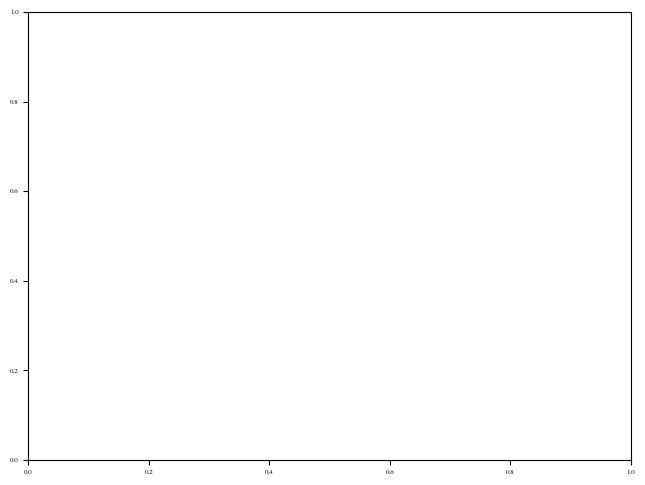

In [2571]:
fig, ax = plt.subplots()

ax = layout.axes[('PCA3', 'pca3')]


ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',
    KDE=True, KDE_test=False,
    real_data_loaders=train_loader_unsteady_sham, cmap = "vanimo_r",
    real_colors_list=y_train_unsteady_sham_color,  # Use converted array
    ax=ax
)


layout.append_figure_to_layer(layout.figures['PCA3'], 'PCA3', cleartarget=True)#

In [2579]:
#trig_ids = df_sham_top_on[df_sham_top_on.Trigger_bool==True].obj_id_unique.unique()
trig_ids = df_sham_top_on[df_sham_top_on.Trigger_bool==True].obj_id_unique.unique()
c1xwt_flash = df_sham_top_on[(df_sham_top_on.obj_id_unique.isin(trig_ids)) & (df_sham_top_on['time stamp'].max()>=3000)] #pd.concat([flash_low_top_on,flash_up_top_on ])

### transform the array & labels correctly

unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unsteady_array.shape}")

# get labels
unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric']#.values

unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index#.values

print(f"Updated labels shape: {unsteady_labels.shape}")



#unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']
unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].mean().rename('Mean_z_after_odor')

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_unsteady =  unsteady_array
y_train_unsteady= unsteady_labels
y_train_unsteady_color= unsteady_color
y_train_unsteady_obj = unsteady_objids

# Create datasets and dataloaders
train_dataset_unsteady = CCL.TrajectoryDataset(X_train_unsteady, y_train_unsteady,y_train_unsteady_obj,  normalization_type='zero_mean')
#test_dataset_unsteady = CCL.TrajectoryDataset(X_test_unsteady, y_test_unsteady,y_test_unsteady_obj,  normalization_type='zero_mean')

train_loader_unsteady = CCL.DataLoader(train_dataset_unsteady, batch_size=32, shuffle=False)
#test_loader_unsteady = CCL.DataLoader(test_dataset_unsteady, batch_size=32, shuffle=False)

Result shape: (1182, 191, 4)
Updated labels shape: (1182,)


Using PCA, explained variance: [0.2597884  0.23014233]


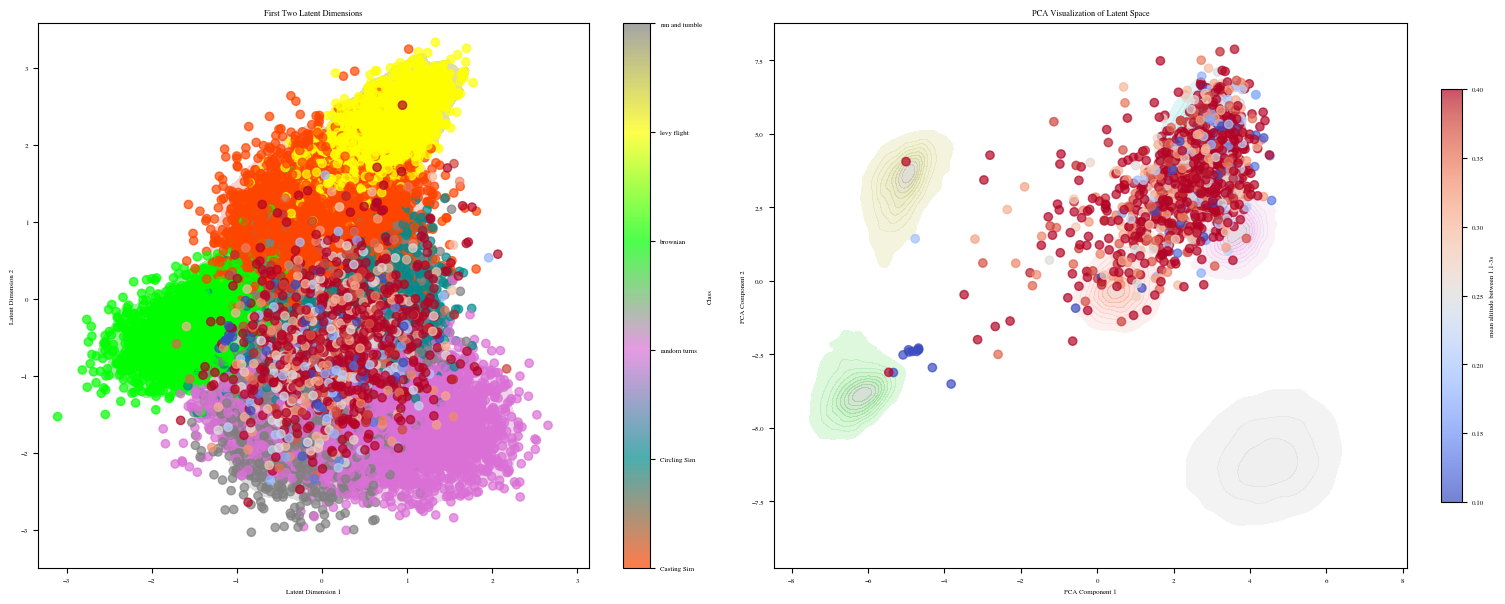

In [2431]:
#fig, ax = plt.subplots()
ax =CCL.plot_latent_space_with_labels(triplet_model, 
                                      test_loader = train_loader, 
                                      labels=y_train,
                                       train_colors=['orangered', 'darkcyan',  'orchid','lime', 'yellow', 'grey'],                                                                                      
                                      real_data_loader=train_loader_unsteady, 
                                      real_data_labels=y_train_unsteady,
                                      # path='latent_imgs/flash_laminar1.svg',                                                             
                                      reduce='PCA', 
                                      n_feats=70, 
                                     KDE=True,
                                      real_colors= y_train_unsteady_color,
                                      plotting_labels=class_labels,)
                                      #real_colors = color_train)

Using PCA, explained variance: [0.2597884  0.23014233]


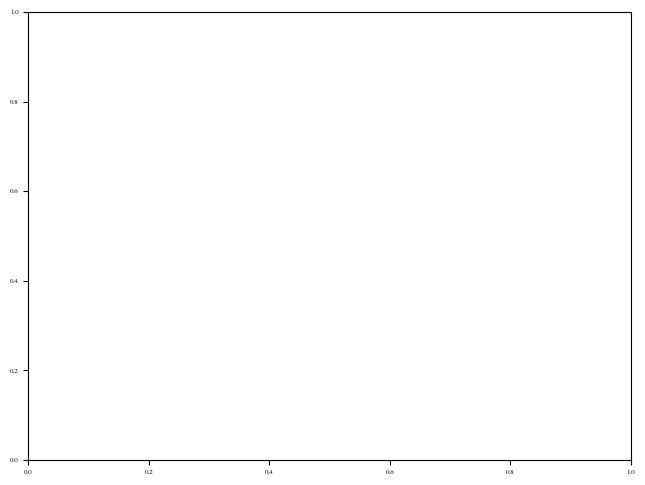

In [2581]:
fig, ax = plt.subplots()

ax = layout.axes[('PCA4', 'pca4')]


ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',
    KDE=True, KDE_test=False,
    real_data_loaders=train_loader_unsteady, cmap = "vanimo_r",
    real_colors_list=y_train_unsteady_color,  # Use converted array
    ax=ax
)


layout.append_figure_to_layer(layout.figures['PCA4'], 'PCA4', cleartarget=True)#


In [2575]:
#trig_ids = df_sham_top_on[df_sham_top_on.Trigger_bool==True].obj_id_unique.unique()
trig_ids = df_sham_bottom_on[df_sham_bottom_on.Trigger_bool==True].obj_id_unique.unique()
c1xwt_flash = df_sham_bottom_on[(df_sham_bottom_on.obj_id_unique.isin(trig_ids)) & (df_sham_bottom_on['time stamp'].max()>=3000)] #pd.concat([flash_low_top_on,flash_up_top_on ])

### transform the array & labels correctly

unsteady_array = np.array([
    group[['x', 'y', 'xvel', 'yvel', ]].values 
    for _, group in c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].sort_values(['obj_id_unique', 'time stamp']).groupby('obj_id_unique')
])

print(f"Result shape: {unsteady_array.shape}")

# get labels
unsteady_labels = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['dataset_numeric']#.values

unsteady_objids = c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first().index#.values

print(f"Updated labels shape: {unsteady_labels.shape}")



#unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']
unsteady_color =  c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].mean().rename('Mean_z_after_odor')

# c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique')['z'].quantile(.90).rename('Mean_z_after_odor')
 #c1xwt_flash[c1xwt_flash['time stamp'].between(1100,3000)].groupby('obj_id_unique').first()['color']#.values




# Now split while maintaining correspondence
X_train_unsteady =  unsteady_array
y_train_unsteady= unsteady_labels
y_train_unsteady_color= unsteady_color
y_train_unsteady_obj = unsteady_objids

# Create datasets and dataloaders
train_dataset_unsteady = CCL.TrajectoryDataset(X_train_unsteady, y_train_unsteady,y_train_unsteady_obj,  normalization_type='zero_mean')
#test_dataset_unsteady = CCL.TrajectoryDataset(X_test_unsteady, y_test_unsteady,y_test_unsteady_obj,  normalization_type='zero_mean')

train_loader_unsteady = CCL.DataLoader(train_dataset_unsteady, batch_size=32, shuffle=False)
#test_loader_unsteady = CCL.DataLoader(test_dataset_unsteady, batch_size=32, shuffle=False)

Result shape: (1307, 191, 4)
Updated labels shape: (1307,)


Using PCA, explained variance: [0.2597884  0.23014233]


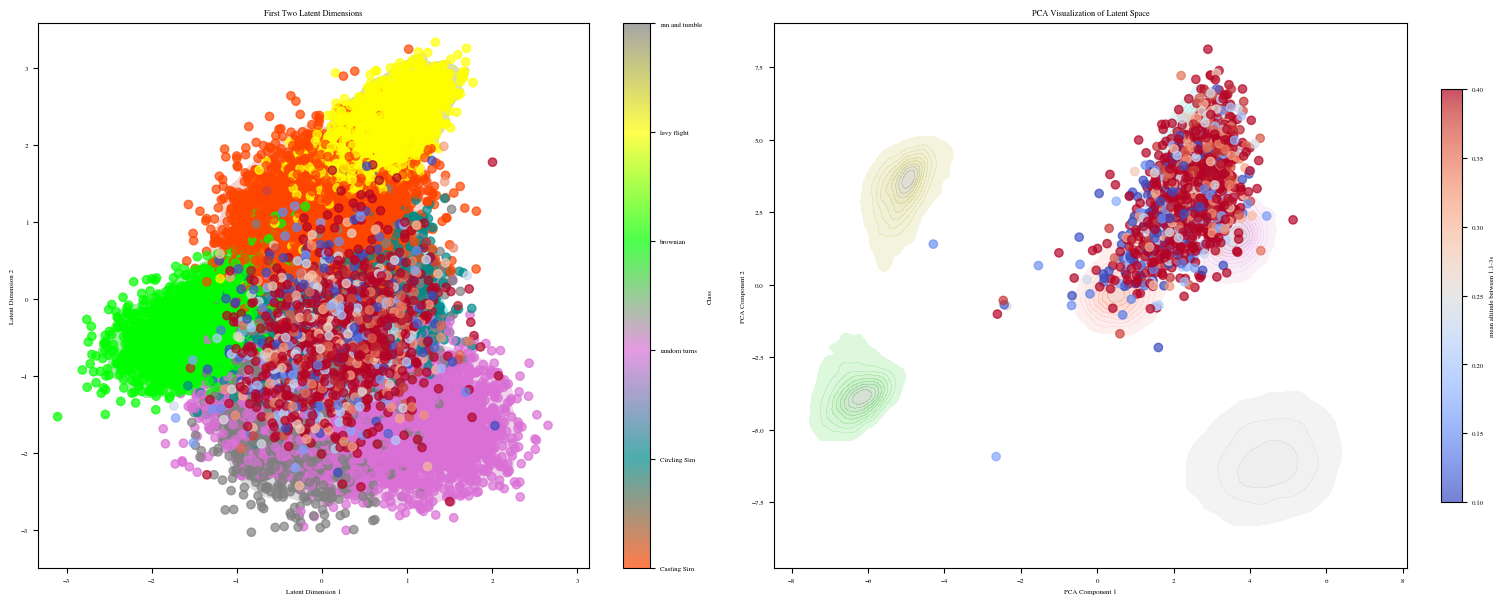

In [2437]:
#fig, ax = plt.subplots()
ax =CCL.plot_latent_space_with_labels(triplet_model, 
                                      test_loader = train_loader, 
                                      labels=y_train,
                                       train_colors=['orangered', 'darkcyan',  'orchid','lime', 'yellow', 'grey'],                                                                                      
                                      real_data_loader=train_loader_unsteady, 
                                      real_data_labels=y_train_unsteady,
                                      # path='latent_imgs/flash_laminar1.svg',                                                             
                                      reduce='PCA', 
                                      n_feats=70, 
                                     KDE=True,
                                      real_colors= y_train_unsteady_color,
                                      plotting_labels=class_labels,)
                                      #real_colors = color_train)

Using PCA, explained variance: [0.25978836 0.2301423 ]


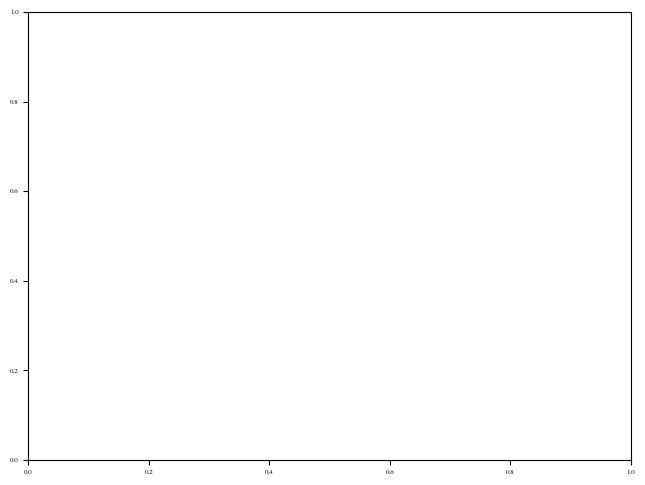

In [2577]:
fig, ax = plt.subplots()

ax = layout.axes[('PCA2', 'pca2')]


ax = plot_latent_space_with_labels(
    model=triplet_model,
    test_loader=train_loader,
    train_colors=['orangered', 'darkcyan', 'orchid', '#dfa45cff', '#a6cd4eff', 'darkviolet'],
    reduce='PCA',
    KDE=True, KDE_test=False,
    real_data_loaders=train_loader_unsteady, cmap = "vanimo",
    real_colors_list=y_train_unsteady_color,  # Use converted array
    ax=ax
)


layout.append_figure_to_layer(layout.figures['PCA2'], 'PCA2', cleartarget=True)#


In [ ]:
layout.write_svg('supp_all_trajectories_altitude_sorted_pca.svg')